In [1]:
from specify_cells import *

numprocs=1


In [2]:
stim_dt = 0.025
dt = 0.025
equilibrate = 250.  # time to steady-state
duration = equilibrate + 100.
ISI = 20.
stochastic = True

In [4]:
cell = Passive_Soma(mech_filename='20241127_single_compartment_biophysics.yaml')

For every synapse that has a Pr, AMPA, and NMDA mechanism, here are the required variables.
If you create many synapses, you will need to keep a reference to each of these objects somewhere after you create them, like a list of dictionary.

In [5]:
cell_id = 0
sec_id = 0
syn_id = 0
loc = 0.5
section = cell.soma[0].sec
syn_source = h.VecStim()

syn_random = h.Random()
# you want a unique random number generator for each cell, each section, and each synapse
syn_random.MCellRan4(cell_id * 10000 + 1, sec_id * 1000 + syn_id + 1)
syn_random.uniform(0, 1)
syn_random.seq()

Pr_syn = h.Pr(section(loc))
Pr_netcon = h.NetCon(syn_source, Pr_syn)
Pr_netcon.delay = 0.
Pr_netcon.weight[0] = 1.
Pr_netcon.threshold = -30.
Pr_syn.setRandObjRef(syn_random)

AMPA_syn = h.AMPA_KIN(section(loc))
AMPA_syn.gmax = 0.00079
AMPA_netcon = h.NetCon(Pr_syn, AMPA_syn)
AMPA_netcon.delay = 0.
AMPA_netcon.weight[0] = 1.
AMPA_netcon.threshold = -30.

NMDA_syn = h.NMDA_KIN5(section(loc))
NMDA_syn.gmax = 0.003026
NMDA_netcon = h.NetCon(Pr_syn, NMDA_syn)
NMDA_netcon.delay = 0.
NMDA_netcon.weight[0] = 1.
NMDA_netcon.threshold = -30.

In [6]:
sim = QuickSim(duration, cvode=False, dt=dt)

In [7]:
sim.append_rec(cell, cell.tree.root, description='soma')

In [8]:
stim_train = np.arange(equilibrate, duration, ISI)
syn_source.play(h.Vector(stim_train))

1.0

In [13]:
sim.run()

Simulation runtime:  0.029149293899536133  sec


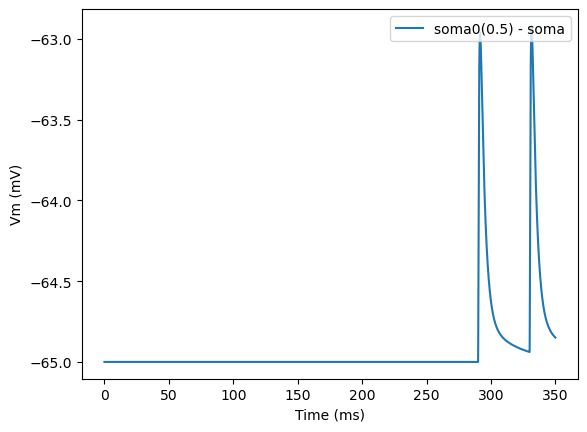

In [14]:
sim.plot()